In [1]:
# Wrapper do BLAST+ para Python
import subprocess
import pandas as pd
import io
import os

def rodar_blast_local(sequencia_fasta, nome_db, output_file="temp_blast.txt"):
    """
    Roda o BLASTn-short para uma sequência contra um banco local.
    Retorna um DataFrame com os hits.
    """
    # 1. Salva a sequência do gene num arquivo temporário
    with open("temp_query.fasta", "w") as f:
        f.write(sequencia_fasta)
        
    # 2. Comando do BLAST (Otimizado para RNAi/Short reads)
    # Nota: Ajuste o caminho do 'blastn' se não estiver no PATH
    cmd = [
        "blastn",
        "-task", "blastn-short",
        "-query", "temp_query.fasta",
        "-db", nome_db,
        "-outfmt", "6 qseqid sseqid pident length qstart qend evalue",
        "-dust", "no", # Desliga filtro de complexidade para achar tudo
        "-word_size", "7",
        "-evalue", "1000", # Permite hits curtos
        "-perc_identity", "100" # Apenas matches idênticos (Risco RNAi)
    ]
    
    # 3. Executa
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    # 4. Processa o resultado em Pandas
    if result.returncode != 0:
        print(f"Erro no BLAST: {result.stderr}")
        return pd.DataFrame()
    
    colunas = ["qseqid", "sseqid", "pident", "length", "qstart", "qend", "evalue"]
    
    # Se não houve hits, retorna vazio
    if not result.stdout:
        return pd.DataFrame(columns=colunas)
        
    df = pd.read_csv(io.StringIO(result.stdout), sep="\t", names=colunas)
    
    # Filtrar apenas hits relevantes para RNAi (>= 19pb)
    df_filtrado = df[df['length'] >= 19].copy()
    
    return df_filtrado

In [2]:
# Gerador de Gráficos de Alinhamento
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plotar_risco_rnai(df_hits, tamanho_gene, titulo_gene, nome_organismo):
    """
    Cria uma visualização gráfica de onde os hits caem no gene.
    """
    fig, ax = plt.subplots(figsize=(12, 3))
    
    # 1. Desenha o Gene (Barra Cinza de fundo)
    ax.add_patch(patches.Rectangle((0, 0.4), tamanho_gene, 0.2, color='lightgray', label='Gene do Fungo'))
    
    # 2. Desenha os Conflitos (Barras Vermelhas)
    # Se houver hits, plota cada um
    if not df_hits.empty:
        for _, row in df_hits.iterrows():
            start = min(row['qstart'], row['qend'])
            width = abs(row['qend'] - row['qstart']) + 1
            
            # Adiciona retângulo vermelho nas coordenadas do hit
            ax.add_patch(patches.Rectangle((start, 0.4), width, 0.2, color='red', alpha=0.7))
            
        ax.text(0, 0.7, f"ALERTA: {len(df_hits)} regiões de conflito detectadas!", color='darkred', weight='bold')
    else:
        ax.text(0, 0.7, "VERDE: Nenhuma homologia encontrada (Seguro).", color='green', weight='bold')

    # Estilização
    ax.set_xlim(0, tamanho_gene)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Posição no Gene (pb)")
    ax.set_title(f"Mapa de Risco: {titulo_gene} vs. {nome_organismo}")
    
    # Legenda inteligente (só adiciona 'Risco' se tiver hits)
    handles, labels = ax.get_legend_handles_labels()
    if not df_hits.empty:
        patch_risk = patches.Patch(color='red', label='Sequência Idêntica (Off-target)')
        handles.append(patch_risk)
        
    ax.legend(handles=handles, loc='upper right')
    
    plt.tight_layout()
    plt.show()

In [3]:
from Bio import SeqIO

c_abs_CDS_file = '../c_abscissum_data/ncbi_dataset/data/GCA_023376855.1/cds_from_genomic.fna'
c_abs_genes = SeqIO.index(c_abs_CDS_file, "fasta")

--- INICIANDO ANÁLISE DE RISCO MULTI-ESPÉCIE ---

ANALISANDO: Scytalone Dehydratase (576 pb)
 -> Verificando contra: db_citrus...


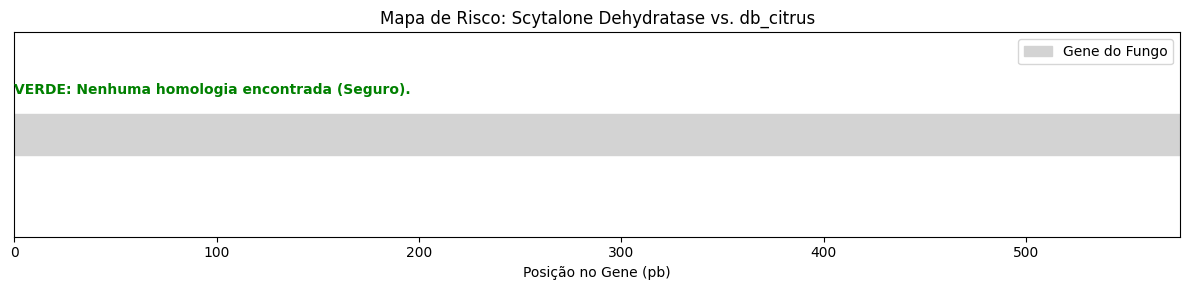

 -> Verificando contra: db_human...


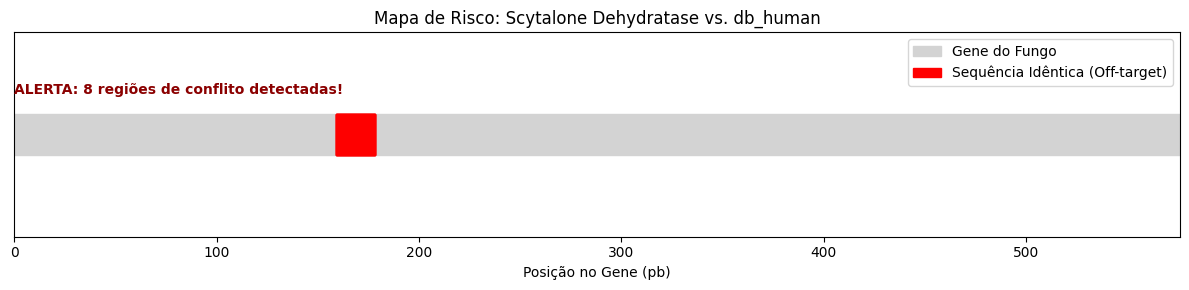

 -> Verificando contra: db_bee...


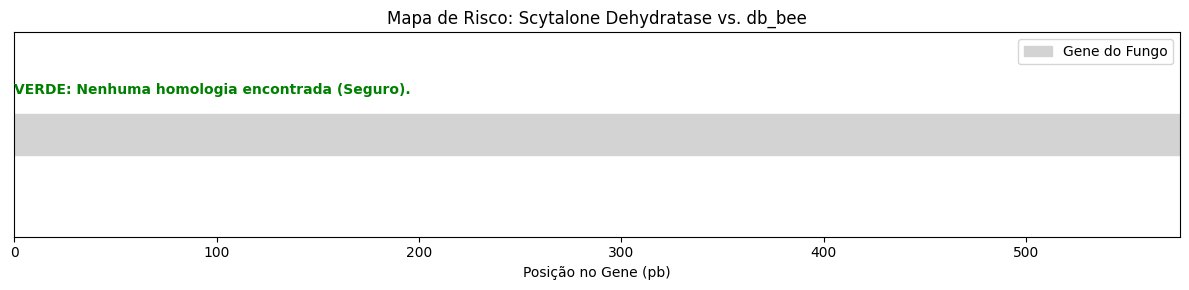



ANALISANDO: Actina (Controle) (1347 pb)
 -> Verificando contra: db_citrus...


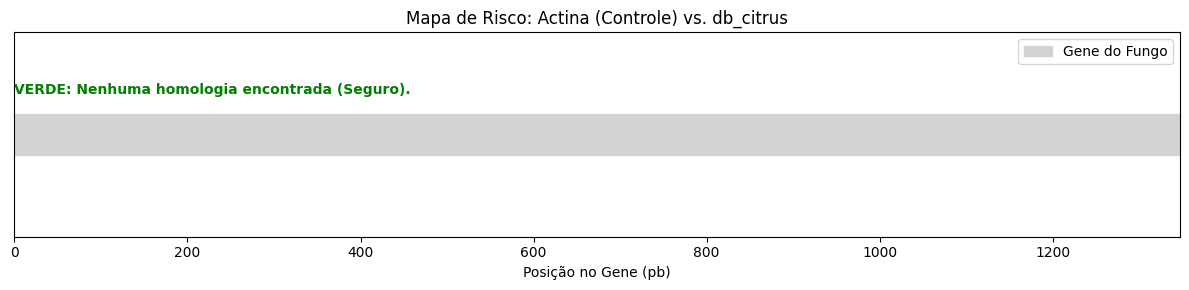

 -> Verificando contra: db_human...


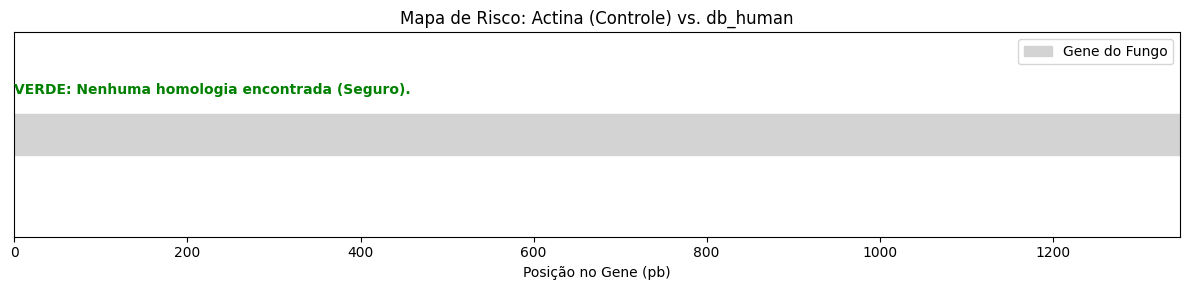

 -> Verificando contra: db_bee...


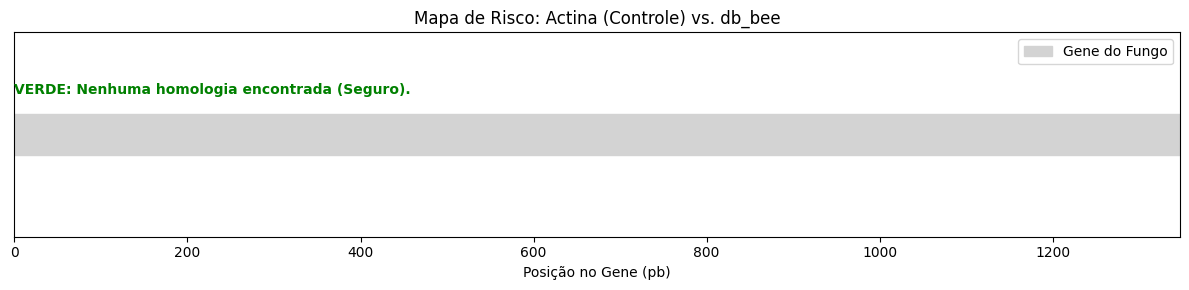

In [4]:
# Execução em Lote (Batch)

# 1. Seus Genes Candidatos (Exemplo: dicionário ID -> Sequência)
# Num cenário real, você leria isso do arquivo 'genes_candidatos.fasta' usando SeqIO
genes_para_teste = {
    "Scytalone Dehydratase": str(c_abs_genes["lcl|SDAQ01000016.1_cds_KAI3555617.1_3992"].seq),
    "Actina (Controle)": str(c_abs_genes["lcl|SDAQ01000033.1_cds_KAI3553165.1_6722"].seq)
}

# 2. Seus Bancos de Organismos (Nomes que você deu no makeblastdb)
bancos_offtarget = ["db_citrus", "db_human", "db_bee"] 

print(f"--- INICIANDO ANÁLISE DE RISCO MULTI-ESPÉCIE ---\n")

for nome_gene, sequencia in genes_para_teste.items():
    tamanho = len(sequencia)
    print(f"==================================================")
    print(f"ANALISANDO: {nome_gene} ({tamanho} pb)")
    print(f"==================================================")
    
    # Formata como FASTA para o BLAST
    fasta_formatado = f">{nome_gene}\n{sequencia}"
    
    for db in bancos_offtarget:
        print(f" -> Verificando contra: {db}...")
        
        # 1. Roda BLAST
        df_resultado = rodar_blast_local(fasta_formatado, db)
        
        # 2. Gera o Gráfico
        plotar_risco_rnai(df_resultado, tamanho, nome_gene, db)
        
    print("\n")

In [5]:
# Varredura em Massa (High-Throughput Screening)
import subprocess
import pandas as pd
from Bio import SeqIO
import os

# --- 1. CONFIGURAÇÃO ---
# Nome do arquivo com TODOS os genes do fungo
arquivo_query = "../c_abscissum_data/ncbi_dataset/data/GCA_023376855.1/cds_from_genomic.fna"

# Dicionário dos Bancos de Dados (Nome de Exibição : Nome do Arquivo DB)
bancos_alvo = {
    "Citrus": "db_citrus",
    "Human":  "db_human",
    "Bee":    "db_bee"
}

# Critérios de Risco (Para RNAi)
MIN_LENGTH = 21  # Tamanho mínimo do match
MIN_IDENT = 100  # Identidade (100% igual)

# --- 2. FUNÇÃO DE BLAST EM LOTE ---
def rodar_blast_batch(query_file, db_name, output_temp):
    """Roda BLASTn para o arquivo inteiro de uma vez (Muito mais rápido)"""
    cmd = [
        "blastn",
        "-task", "blastn-short",
        "-query", query_file,
        "-db", db_name,
        "-out", output_temp,
        "-outfmt", "6 qseqid length pident", # Formato tabular leve
        "-word_size", "7",
        "-evalue", "1000",
        "-perc_identity", "100", # Só aceita 100%
        "-num_threads", "4"      # Ajuste conforme seu processador
    ]
    # Executa sem mostrar output no console
    subprocess.run(cmd, check=True)

# --- 3. EXECUÇÃO ---
print(f"--- INICIANDO VARREDURA DE BIOSSEGURANÇA ---")
print(f"Lendo genes do fungo em: {arquivo_query}...")

# 3.1 Carregar todos os IDs do fungo na memória
todos_genes = []
for record in SeqIO.parse(arquivo_query, "fasta"):
    todos_genes.append(record.id)

print(f"Total de genes para analisar: {len(todos_genes)}")
print("-" * 60)

# Dicionário para guardar quem é perigoso em qual espécie
# Estrutura: { "id_gene": {"Citrus": True/False, "Human": True/False...} }
riscos = {gene: {sp: False for sp in bancos_alvo} for gene in todos_genes}

# 3.2 Loop pelos Bancos (Roda BLAST 3 vezes apenas)
for species_name, db_file in bancos_alvo.items():
    print(f"Processando banco: {species_name}...", end=" ")
    temp_file = f"temp_results_{species_name}.txt"
    
    try:
        # Roda o BLAST
        rodar_blast_batch(arquivo_query, db_file, temp_file)
        
        # Lê o resultado
        # Se o arquivo estiver vazio (nenhum match), o Pandas gera erro, então tratamos isso
        if os.path.getsize(temp_file) > 0:
            df = pd.read_csv(temp_file, sep="\t", names=["qseqid", "length", "pident"])
            
            # Filtra pelos critérios de RNAi
            df_perigoso = df[df['length'] >= MIN_LENGTH]
            
            # Marca os genes perigosos no dicionário
            genes_com_match = df_perigoso['qseqid'].unique()
            for gene in genes_com_match:
                if gene in riscos:
                    riscos[gene][species_name] = True
            
            print(f"[CONCLUÍDO] - {len(genes_com_match)} conflitos detectados.")
        else:
            print(f"[CONCLUÍDO] - 0 conflitos (Banco Seguro).")
            
    except Exception as e:
        print(f"[ERRO] Falha ao processar {species_name}: {e}")
        # Se der erro, assume risco para não dar falso negativo
        for gene in riscos:
            riscos[gene][species_name] = "ERRO"

# --- 4. RELATÓRIO LINHA A LINHA ---
print("\n" + "="*80)
print(f"{'GENE ID':<40} | {'CITRUS':<10} | {'HUMAN':<10} | {'BEE':<10}")
print("="*80)

# Contadores para resumo final
aprovados = 0

for gene in todos_genes:
    status_line = f"{gene[:37]:<40} | " # Corta ID longo
    is_safe_total = True
    
    for sp in bancos_alvo:
        r = riscos[gene][sp]
        if r == True:
            status_line += f"❌ RISK     | " # Vermelho (mentalmente)
            is_safe_total = False
        elif r == "ERRO":
            status_line += f"⚠️ ERRO     | "
            is_safe_total = False
        else:
            status_line += f"✅ Safe     | "
            
    print(status_line)
    
    if is_safe_total:
        aprovados += 1

print("="*80)
print(f"RESUMO FINAL:")
print(f"Total Analisado: {len(todos_genes)}")
print(f"Genes 100% Seguros (Aprovados para RNAi): {aprovados}")
print(f"Genes com Risco de Off-target: {len(todos_genes) - aprovados}")

--- INICIANDO VARREDURA DE BIOSSEGURANÇA ---
Lendo genes do fungo em: ../c_abscissum_data/ncbi_dataset/data/GCA_023376855.1/cds_from_genomic.fna...
Total de genes para analisar: 15499
------------------------------------------------------------
Processando banco: Citrus... 

KeyboardInterrupt: 